<a href="https://colab.research.google.com/github/RAseng77/computer_vision_study/blob/main/%EC%BB%B4%ED%93%A8%ED%84%B0%EA%B8%B0%EB%B3%B8_%EA%B8%B0%EC%B4%88/%EA%B0%80%EC%9C%84%EB%B0%94%EC%9C%84%EB%B3%B4%EB%B6%84%EB%A5%98%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. 데이터 준비하기

In [1]:
import torch
torch.cuda.is_available()

True

In [2]:
import os
import random
import shutil

In [4]:
from google.colab import drive

# 드라이브 마운트
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
data_root = '/content/drive/MyDrive/file/rock_paper_scissors'

file_root = f"{data_root}/rock_paper_scissors"
train_root = f"{data_root}/train"
valid_root = f"{data_root}/valid"
test_root = f"{data_root}/test"

cls_list = os.listdir(file_root)
print(cls_list)

['paper', 'scissors', 'rock']


In [10]:
for folder in [train_root, valid_root, test_root]:
  if not os.path.exists(folder):
    os.mkdir(folder)
  for cls in cls_list:
    cls_folder = f"{folder}/{cls}"
    if not os.path.exists(cls_folder):
      os.mkdir(cls_folder)

In [ ]:
for cls in cls_list:
  file_list = os.listdir(f"{file_root}/{cls}")
  random.shuffle(file_list)

  test_ratio = 0.1
  num_file = len(file_list)

  test_list = file_list[:int(num_file * test_ratio)]
  valid_list = file_list[int(num_file * test_ratio): int(num_file * test_ratio * 2)]
  train_list = file_list[int(num_file * test_ratio * 2): ]

  for i in train_list:
    shutil.copyfile(f"{file_root}/{cls}/{i}", f"{train_root}/{cls}/{i}")

  for i in valid_list:
    shutil.copyfile(f"{file_root}/{cls}/{i}", f"{valid_root}/{cls}/{i}")

  for i in test_list:
    shutil.copyfile(f"{file_root}/{cls}/{i}", f"{test_root}/{cls}/{i}")

In [39]:
!find "/content/drive/MyDrive/file/rock_paper_scissors" -name ".DS_Store" -type f -delete

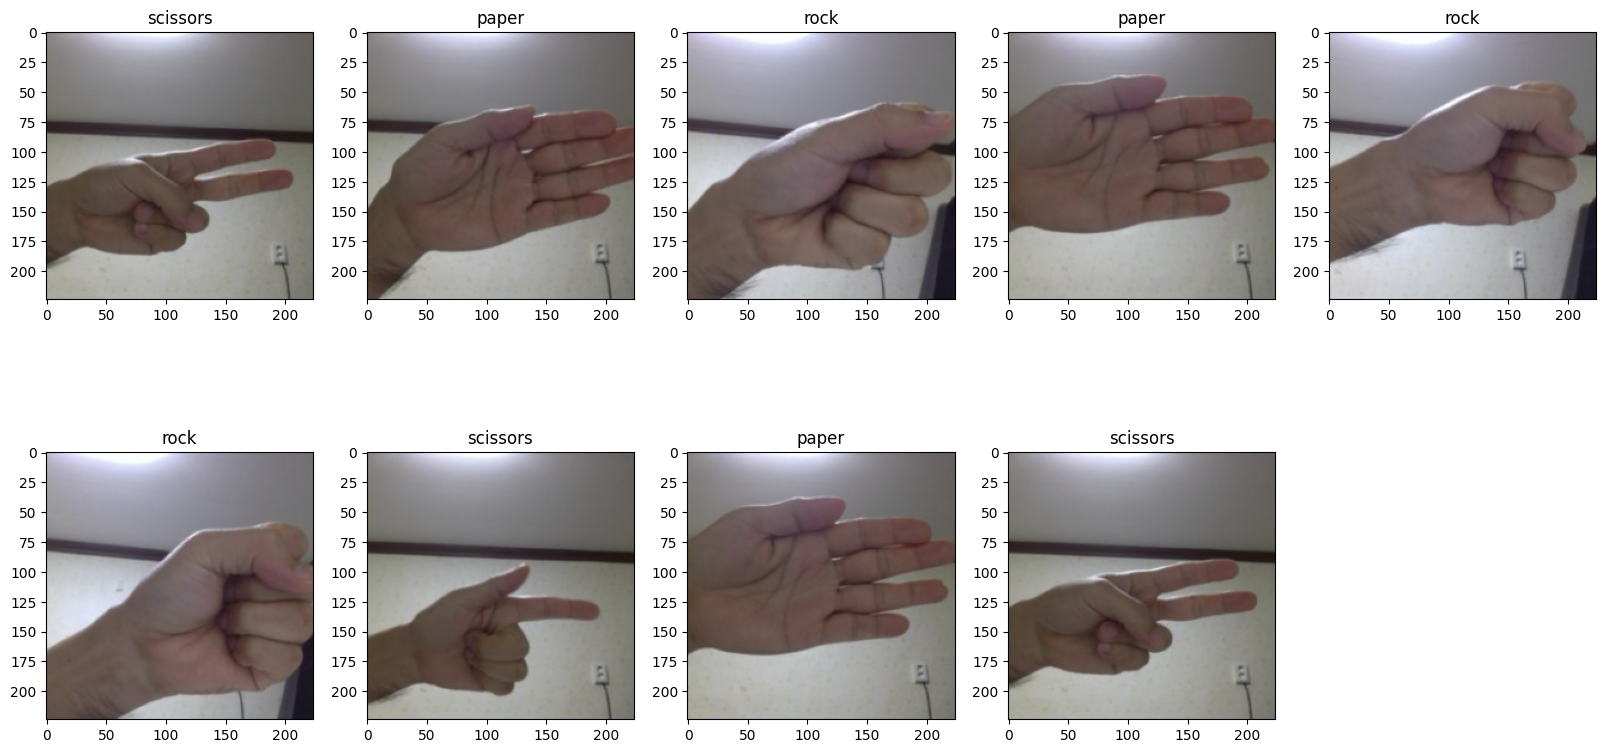

In [11]:
import matplotlib.pyplot as plt
import glob
from PIL import Image

# test_root 안에 있는 모든 클래스 폴더의 이미지 파일 경로를 리스트로 가져옴
test_file_list = glob.glob(f"{test_root}/*/*")

# 가져온 이미지 경로 리스트를 무작위로 섞어서 랜덤하게 시각화 할 수 있도록 준비
random.shuffle(test_file_list)

# 출력 이미지 크기 지정
plt.figure(figsize=(20, 10))

# 처음 10장의 이미지 그리기
for i in range(9):
  # test_root 경로와 파일 경로를 합쳐 최종 이미지 파일 경로 생성
  test_img_path = os.path.join(test_root, test_file_list[i])
  ori_img = Image.open(test_img_path)
  plt.subplot(2, 5, (i+1))
  plt.title(test_file_list[i].split('/')[-2])
  plt.imshow(ori_img)

plt.show()



## 2. 데이터 전처리

In [12]:
import os
import torch
import torchvision
from torchvision import datasets, models, transforms

In [13]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(228),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'valid': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(228),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(228),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

In [24]:
# ImageFolder를 이용해 train, valid, test 데이터셋을 각각 생성
image_datasets = {x: datasets.ImageFolder(os.path.join(data_root, x),   # data_root/train, data_root/test, data_root/valid 경로
                                          data_transforms[x])           # 해당 split에 맞는 transform 적용
                    for x in ['train', 'valid', 'test']
                  }

# DataLoader를 생성 (배치 단위로 데이터를 꺼내오기 위해)
# num_workers=0 -> 데이터 로딩에 사용할 subprocess 수 (Colab/Windows에서는 보통 0)
dataloaders = {
    x: torch.utils.data.DataLoader(image_datasets[x],
                                   batch_size=16,
                                   shuffle=True,
                                   num_workers=0)
    for x in ['train', 'valid', 'test']
}

# 각 데이터셋(train/valid/test)의 이미지 개수를 딕셔너리 형태로 저장
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'valid', 'test']}

# train 데이터셋의 클래스 이름(폴더 이름)을 가져옴
class_names = image_datasets['train'].classes

print('dataset_sizes: ',dataset_sizes)
print('class_names: ',class_names)

dataset_sizes:  {'train': 77, 'valid': 9, 'test': 9}
class_names:  ['paper', 'rock', 'scissors']


## 3. Training

In [15]:
import os
import torch
import torch.nn.functional as F

from tempfile import TemporaryDirectory
from time import time
from tqdm import tqdm

import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

In [16]:
pjt_root = '/content/drive/MyDrive/file/rock_paper_scissors/project'
model_dir = f"{pjt_root}/models"
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(DEVICE)


cuda:0


In [32]:
def train_model(model, criterion, optimizer, dataloaders, dataset_sizes, device, model_dir, model_name, num_epochs=25):
    print(device)   # 현재 학습에 사용할 디바이스(CPU/GPU) 출력
    since = time()  # 학습 시작 시각 기록

    # 임시 디렉토리를 생성하여 학습 중간 결과(체크포인트)를 저장
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        # 현재 모델의 초기 파라미터를 저장 (최고 성능 모델 갱신용)
        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0    # 최고 검증 정확도 저장 변수
        train_loss = []   # 학습 손실 기록
        train_acc = []    # 학습 정확도 기록
        valid_loss = []   # 검증 손실 기록
        valid_acc = []    # 검증 정확도 기록

        # 전체 epoch 반복
        for epoch in range(num_epochs):
            print(f'Epoch: {epoch+1}/{num_epochs}')
            print('-' * 10)

            # 각 epoch은 train 단계와 valid 단계로 나눔
            for phase in ['train', 'valid']:
                if phase == 'train':
                    model.train()   # 학습 단계
                else:
                    model.eval()    # 평가 모드

                running_loss = 0.0   # epoch 동안의 누적 손실
                running_corrects = 0 # epoch 동안의 올바른 예측 수

                # 데이터 배치 단위 반복
                for inputs, labels in tqdm(dataloaders[phase]):
                    inputs, labels = inputs.to(device), labels.to(device)

                    # 이전 step의 gradient 초기화
                    optimizer.zero_grad()

                    # forward (train일 때만 gradient 추적)
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)  # 모델 예측 결과
                        _, preds = torch.max(outputs, 1)  # 가장 높은 확률의 클래스 선택
                        loss = criterion(outputs, labels) # 손실 계산

                        # 학습 단계라면 역전파 및 최적화 진행
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # 통계 기록 (손실과 정확도 누적)
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)

                # epoch 단위 평균 손실과 정확도 계산
                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
                if phase == 'train':
                    # 학습 기록 저장
                    train_loss.append(epoch_loss)
                    train_acc.append(epoch_acc.item())
                else:
                    # 검증 기록 저장
                    valid_loss.append(epoch_loss)
                    valid_acc.append(epoch_acc.item())
                    # 최고 성능 모델 갱신
                    if epoch_acc > best_acc:
                        best_acc = epoch_acc

                        # 모델 저장 폴더 없으면 생성
                        if not os.path.exists(model_dir):
                            os.makedirs(model_dir)

                        # 현재 모델 파라미터 저장
                        model_save_path = os.path.join(model_dir, f'{model_name}.pth')
                        torch.save(model.state_dict(), model_save_path)

            print()

        # 전체 학습 시간 측정 및 출력
        time_elapsed = time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:.4f}')

    # 학습 과정에서 기록한 손실/정확도 리스트 반환
    return [train_loss, valid_loss, train_acc, valid_acc]


In [21]:
# 학습 데이터셋 폴더 안의 클래스 개수를 자동으로 계산
num_class = len(os.listdir(train_root))

# VGG16 모델 불러오기
vgg_model = models.vgg16(pretrained=True)

# VGG16의 분류기 마지막 레이어를 바꿔줌
vgg_model.classifier[6] = nn.Linear(4096, num_class)

# 모델을 GPU 또는 CPU로 이동
vgg_model = vgg_model.to(DEVICE)

# 손실 함수 정의
criterion = nn.CrossEntropyLoss()

# 최적화 함수 적용
optimizer = optim.SGD(vgg_model.parameters(), lr=0.00005, momentum=0.9)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 76.0MB/s]


In [33]:
num_epochs = 20
vgg = train_model(vgg_model, criterion, optimizer,dataloaders, dataset_sizes, DEVICE, model_dir, 'rsp_vgg', num_epochs =num_epochs)

cuda:0
Epoch: 1/20
----------


100%|██████████| 5/5 [00:01<00:00,  2.75it/s]


train Loss: 0.5807 Acc: 0.9091


100%|██████████| 1/1 [00:00<00:00,  9.11it/s]


valid Loss: 0.3965 Acc: 1.0000

Epoch: 2/20
----------


...

valid Loss: 0.0581 Acc: 1.0000

Epoch: 20/20
----------


100%|██████████| 5/5 [00:01<00:00,  2.72it/s]


train Loss: 0.1931 Acc: 0.9740


100%|██████████| 1/1 [00:00<00:00, 10.06it/s]

valid Loss: 0.0542 Acc: 1.0000

Training complete in 0m 54s
Best val Acc: 1.0000


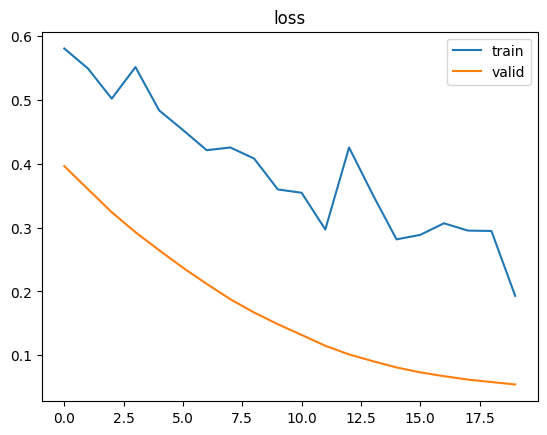

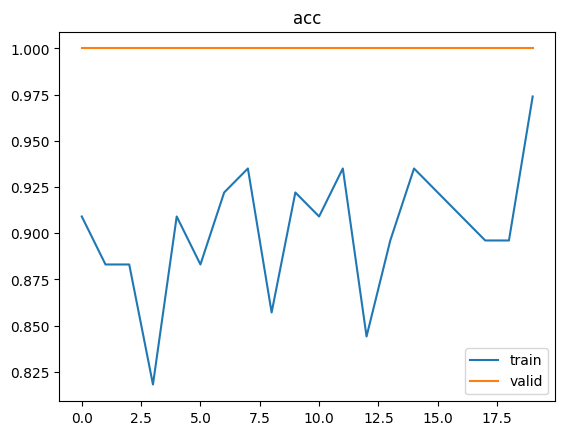

In [34]:
import matplotlib.pyplot as plt

plt.title("loss")
plt.plot(vgg[0], label='train')
plt.plot(vgg[1], label='valid')
plt.legend()
plt.show()

plt.title('acc')
plt.plot(vgg[2], label='train')
plt.plot(vgg[3], label='valid')
plt.legend()
plt.show()

In [35]:
print(vgg)

[[0.5807414705103094, 0.5493131314779257, 0.5021294185093471, 0.5515666147331139, 0.4836090555438748, 0.45301946997642517, 0.4213753098791296, 0.42559706777721257, 0.40820332897173894, 0.3598209743375902, 0.3546924718788692, 0.2971024668061888, 0.4255865870358108, 0.35170321572910657, 0.2816354013108588, 0.28866218572313135, 0.30683757964666786, 0.2954470298506997, 0.29474683705862464, 0.19310123812068591], [0.39649879932403564, 0.3601783812046051, 0.32423657178878784, 0.29285186529159546, 0.2645643651485443, 0.23720389604568481, 0.21189728379249573, 0.18775247037410736, 0.16700464487075806, 0.1486336588859558, 0.13193082809448242, 0.11487311869859695, 0.10136464238166809, 0.09075921028852463, 0.0809740498661995, 0.07321260869503021, 0.06726989150047302, 0.06193649768829346, 0.058058738708496094, 0.05424555018544197], [0.9090909090909092, 0.8831168831168832, 0.8831168831168832, 0.8181818181818182, 0.9090909090909092, 0.8831168831168832, 0.9220779220779222, 0.9350649350649352, 0.8571428

In [38]:
num_class = len(os.listdir(train_root))
alexnet_model = models.alexnet(pretrained=True)

alexnet_model.classifier[6] = nn.Linear(4096, num_class)

alexnet_model = alexnet_model.to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(alexnet_model.parameters(), lr=0.00005, momentum=0.9)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 105MB/s] 


In [39]:
num_epochs = 20
alexnet = train_model(alexnet_model, criterion, optimizer,dataloaders, dataset_sizes, DEVICE, model_dir, 'rsp_alexnet', num_epochs =num_epochs)

cuda:0
Epoch: 1/20
----------


100%|██████████| 5/5 [00:01<00:00,  3.90it/s]


train Loss: 1.0785 Acc: 0.3506


100%|██████████| 1/1 [00:00<00:00, 16.22it/s]


valid Loss: 1.0543 Acc: 0.4444

Epoch: 2/20
----------


...

valid Loss: 0.1056 Acc: 1.0000

Epoch: 20/20
----------


100%|██████████| 5/5 [00:00<00:00,  8.10it/s]


train Loss: 0.2601 Acc: 0.9351


100%|██████████| 1/1 [00:00<00:00, 14.10it/s]


valid Loss: 0.0969 Acc: 1.0000

Training complete in 0m 24s
Best val Acc: 1.0000


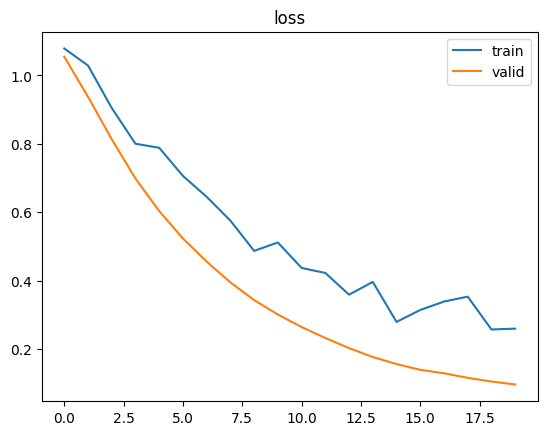

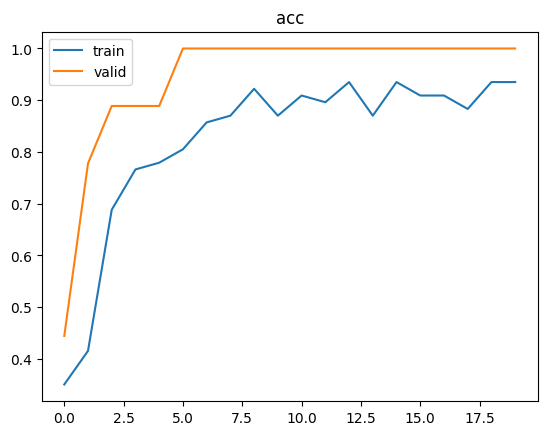

In [40]:
import matplotlib.pyplot as plt

plt.title("loss")
plt.plot(alexnet[0], label='train')
plt.plot(alexnet[1], label='valid')
plt.legend()
plt.show()

plt.title("acc")
plt.plot(alexnet[2], label='train')
plt.plot(alexnet[3], label='valid')
plt.legend()
plt.show()

In [41]:
print(alexnet)

[[1.078511736609719, 1.0287384414053582, 0.9046770024609256, 0.8001939321493173, 0.7883739842996969, 0.70626687384271, 0.6450787294994701, 0.575605668030776, 0.4871826891775255, 0.5116569167607791, 0.43737083441251284, 0.42266142639246856, 0.3593284112292451, 0.3965217850425027, 0.27971862701626565, 0.31450286701128083, 0.3390987941196987, 0.35352806843720475, 0.2575106206652406, 0.26005498890752915], [1.0543397665023804, 0.9375321269035339, 0.8133081793785095, 0.6985107660293579, 0.6035876870155334, 0.5234662294387817, 0.4558161497116089, 0.3952196538448334, 0.3434894382953644, 0.301249235868454, 0.26467403769493103, 0.2327391803264618, 0.20308060944080353, 0.17709019780158997, 0.15660646557807922, 0.1396390050649643, 0.12969142198562622, 0.1162424087524414, 0.10555943846702576, 0.0968795120716095], [0.35064935064935066, 0.4155844155844156, 0.6883116883116883, 0.7662337662337663, 0.7792207792207793, 0.8051948051948052, 0.8571428571428572, 0.8701298701298702, 0.9220779220779222, 0.8701

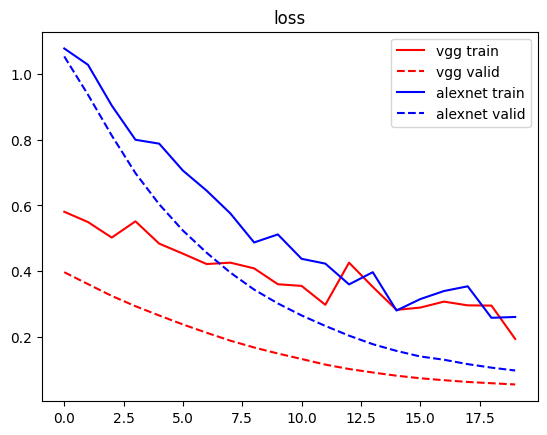

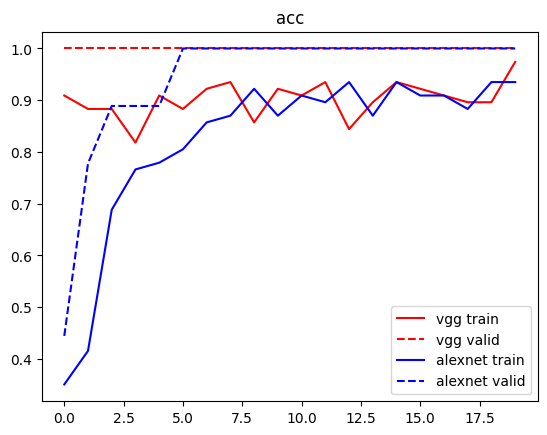

In [42]:
import matplotlib.pyplot as plt

plt.title("loss")
plt.plot(vgg[0],'r-', label='vgg train')
plt.plot(vgg[1],'r--', label='vgg valid')
plt.plot(alexnet[0],'b-', label='alexnet train')
plt.plot(alexnet[1],'b--', label='alexnet valid')
plt.legend()
plt.show()

plt.title("acc")
plt.plot(vgg[2],'r-', label='vgg train')
plt.plot(vgg[3],'r--', label='vgg valid')
plt.plot(alexnet[2],'b-', label='alexnet train')
plt.plot(alexnet[3],'b--', label='alexnet valid')
plt.legend()
plt.show()

## 4. Testing

In [44]:
import os
import torch
import torch.nn.functional as F
from tempfile import TemporaryDirectory
from time import time
from tqdm import tqdm

import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision.models as models
from torchvision import datasets, transforms

from PIL import Image
import matplotlib.pyplot as plt
import glob

In [45]:
data_root = '/content/drive/MyDrive/file/rock_paper_scissors'
pjt_root = '/content/drive/MyDrive/file/rock_paper_scissors/project'
test_root = f'{data_root}/test'
test_file_list = glob.glob(f"{test_root}/*/*")

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda:0


In [46]:
# 테스트 데이터에 적용할 전처리(transform) 정의
test_data_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(228),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# test 폴더 안의 하위 폴더 구조(class별)로 ImageFolder 객체 생성
image_test = datasets.ImageFolder(
    os.path.join(data_root, 'test'),    # 테스트 데이터 경로
    test_data_transform
)

# 테스트용 DataLoader 생성
test_dataloader = torch.utils.data.DataLoader(
    image_test, batch_size=16, shuffle=False, num_workers=0
)

# 테스트 데이터 전체 샘플 수
test_dataset_size = len(image_test)

# 클래스 이름 리스트 (폴더 이름 기준)
class_names = image_test.classes


In [48]:
def test_model(model, criterion, dataloader, dataset_size, device):
  print(device)
  since = time()

  model.eval()    # 평가 모드로 설정

  running_loss = 0.0    # 전체 테스트 손실 누적
  running_corrects = 0  # 전체 맞춘 개수 누적

  # 테스트 데이터 배치 단위 반복
  for inputs, labels in tqdm(dataloader):
    inputs, labels = inputs.to(device), labels.to(device)

    # 평가 단계에서는 gradient 계산 필요 없음
    with torch.no_grad():
      outputs = model(inputs)   # 모델 예측 결과
      _, preds = torch.max(outputs, 1)  # 가장 높은 확률의 클래스 선택
      loss = criterion(outputs, labels) # 손실 계산

    # 손실 및 정확도 통계 누적
    running_loss += loss.item() * inputs.size(0)
    running_corrects += torch.sum(preds == labels.data)

  # 전체 데이터셋 기준 평균 손실과 정확도
  epoch_loss = running_loss / dataset_size
  epoch_acc = running_corrects.double() / dataset_size

  # 테스트 수행 시간 출력
  time_elapsed = time() - since
  print(f'Test complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
  print(f'Acc: {epoch_acc:.4f} Loss: {epoch_loss:.4f}')

In [49]:
# 테스트 데이터셋에 있는 클래스(폴더) 개수를 계산
num_class = len(os.listdir(test_root))

# 사전 학습된 가중치 없이 VGG16 모델 구조만 불러오기
vgg_model = models.vgg16(pretrained=False)

vgg_model.classifier[6] = nn.Linear(4096, num_class)

vgg_model = vgg_model.to(DEVICE)

# 학습이 끝난 모델 가중치 파일(.pth) 경로 설정
cp_path = f"{pjt_root}/models/rsp_vgg.pth"

# 저장된 모델 파라미터를 불러와 현재 vgg_model에 적용
vgg_model.load_state_dict(torch.load(cp_path, map_location=DEVICE))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


<All keys matched successfully>

In [50]:
criterion = nn.CrossEntropyLoss()
test_model(vgg_model, criterion, test_dataloader, test_dataset_size, DEVICE)

cuda:0


100%|██████████| 1/1 [00:00<00:00,  7.47it/s]

Test complete in 0m 0s
Acc: 1.0000 Loss: 0.4128


In [51]:
num_class = len(os.listdir(test_root))
alexnet_model = models.alexnet(pretrained=False)
alexnet_model.classifier[6] = nn.Linear(4096, num_class)
alexnet_model = alexnet_model.to(DEVICE)

cp_path = f"{pjt_root}/models/rsp_alexnet.pth"
alexnet_model.load_state_dict(torch.load(cp_path, map_location=DEVICE))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


<All keys matched successfully>

In [52]:
criterion = nn.CrossEntropyLoss()
test_model(alexnet_model, criterion, test_dataloader, test_dataset_size, DEVICE)

cuda:0


100%|██████████| 1/1 [00:00<00:00, 17.77it/s]

Test complete in 0m 0s
Acc: 1.0000 Loss: 0.4842


## 5. Inference

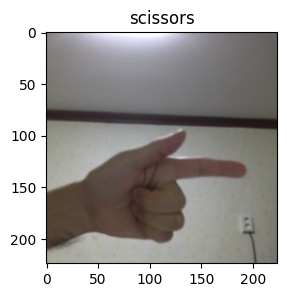

In [60]:
# 테스트할 이미지 파일 경로 지정
test_img_path = os.path.join(test_root, test_file_list[4])

# 원본 이미지를 열기 (PIL Image 객체)
ori_img = Image.open(test_img_path)

# 정의해 둔 test_data_transform 적용
image = test_data_transform(ori_img)

# 텐서로 변환된 이미지를 모델 입력 형식(batch 차원 포함)으로 맞추기
x_tensor = image.to(DEVICE).unsqueeze(0)

# 모델 추론 수행 (forward)
outputs = vgg_model(x_tensor)

# 가장 높은 확률을 가진 클래스 선택
_, y_pred = torch.max(outputs, 1)

# 결과 시각화
plt.figure(figsize=(3,3))
plt.title(class_names[y_pred])
plt.imshow(ori_img)
plt.show()
